In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



In [49]:
voc_size=5000
maxlen=100
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=voc_size)
x_train=pad_sequences(x_train,maxlen=maxlen)
x_test=pad_sequences(x_train,maxlen=maxlen)

In [51]:
print(x_train)

[[1415   33    6 ...   19  178   32]
 [ 163   11 3215 ...   16  145   95]
 [1301    4 1873 ...    7  129  113]
 ...
 [  11    6 4065 ...    4 3586    2]
 [ 100 2198    8 ...   12    9   23]
 [  78 1099   17 ...  204  131    9]]


In [53]:
print(y_train)

[1 0 0 ... 0 1 0]


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,Dropout


In [57]:
model = Sequential([
    Embedding(input_dim=voc_size, output_dim=64),  # smaller embedding
    SimpleRNN(64, return_sequences=True, dropout=0.5, recurrent_dropout=0.5),
    SimpleRNN(32, return_sequences=False, dropout=0.5, recurrent_dropout=0.5),
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [59]:
model.build(input_shape=(None, maxlen))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 100, 64)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_6 (SimpleRNN)             │ (None, 100, 64)             │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_7 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 331,905 (1.27 MB)

 Trainable params: 331,905 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       
    patience=2,               
    restore_best_weights=True 
)
history = model.fit(x_train, y_train,
                    epochs=6,
                    batch_size=128,
                    validation_split=0.2)


Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5020 - loss: 0.9235 - val_accuracy: 0.4988 - val_loss: 0.8034
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5031 - loss: 0.7910 - val_accuracy: 0.4992 - val_loss: 0.7457
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4960 - loss: 0.7381 - val_accuracy: 0.4968 - val_loss: 0.7189
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4982 - loss: 0.7140 - val_accuracy: 0.4938 - val_loss: 0.7057
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5006 - loss: 0.7028 - val_accuracy: 0.4942 - val_loss: 0.6992
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4999 - loss: 0.6975 - val_accuracy: 0.4938 - val_loss: 0.6961


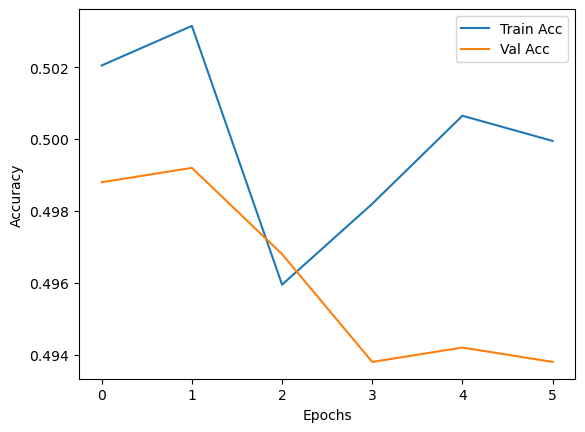

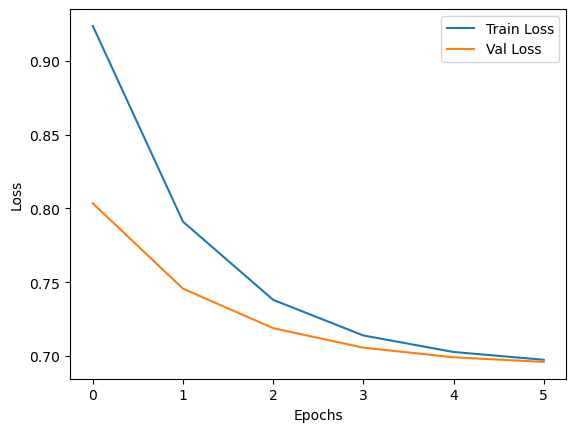

782/782 - 3s - 4ms/step - accuracy: 0.5000 - loss: 0.6959
Test Accuracy: 50.00%
Test Loss: 0.6959


In [63]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.show()
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

In [65]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Parameters
vocab_size = 10000   # top 10k words
maxlen = 200         # max sequence length
embedding_dim = 128  # embedding vector size

# Load IMDB dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences to fixed length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Build model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(128, dropout=0.5, recurrent_dropout=0.5, return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,              # set higher, early stop will cut it short
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 318ms/step - accuracy: 0.6926 - loss: 0.5739 - val_accuracy: 0.8148 - val_loss: 0.3998
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 288ms/step - accuracy: 0.8209 - loss: 0.4160 - val_accuracy: 0.8098 - val_loss: 0.4138
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 280ms/step - accuracy: 0.8547 - loss: 0.3510 - val_accuracy: 0.8058 - val_loss: 0.4297
782/782 - 14s - 18ms/step - accuracy: 0.8244 - loss: 0.3935
Test Accuracy: 82.44%
Test Loss: 0.3935
